# Step 1

## Heston model for call & put options

a. Initially, calibrating the derivative for a very short maturity for the derivative (around 15 days). 

Using classic Heston (1993) model (without jumps) to the observed market prices for both call and put options. Use the Lewis (2001) approach with a regular MSE error function. For the moment, consider a constant annual risk-free rate of 1.50%. Assume 1 year has 250 trading days.

For the case of put options, options to compute:

i. Use the Lewis (2001) closed form for put options on the
paper: Lewis, Alan L. "A simple option formula for general jump-diffusion
and other exponential Lévy processes." (2001)
https://papers.ssrn.com/sol3/papers.cfm?abstract_id=282110

ii. (preferred) Use put-call parity with the closed-form solution for the call
option.

As part of the project, I report the parameter values resulting from the calibration, document the entire process so that it is transparent (including the maturities used for calibration, the error function applied, etc.), and provide a brief discussion of the final calibration, accompanied by graphs that clearly illustrate the quality of the fit.

In [2]:
import pandas as pd
import numpy as np
from numpy.fft import fft
from scipy import stats
from scipy.integrate import quad

C:\Users\USER\anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\USER\anaconda3\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\Users\USER\anaconda3\lib\site-packages\numpy\.libs\libopenblas.PYQHXLVVQ7VESDPUVUADXEVJOBGHJPAY.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


Define Heston characteristic function, Integral and Call value

In [3]:
def H93_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0):

    """Valuation of European call option in H93 model via Lewis (2001)
    Fourier-based approach: characteristic function
    Parameter definitions see function BCC_call_calue"""

    c1 = kappa_v*theta_v
    c2 = -np.sqrt(
        (rho*sigma_v*u*1j-kappa_v)**2 - sigma_v**2*(-u*1j-u**2)
        )
    c3 = (kappa_v-rho*sigma_v*u*1j+c2)/ (
        kappa_v - rho*sigma_v*u*1j - c2)
    H1 = r*u * 1j*T+(c1/sigma_v**2)*(
        (kappa_v-rho*sigma_v*u*1j+c2)*T
        -2*np.log((1-c3*np.exp(c2*T))/(1-c3)))
    H2 = (
        (kappa_v-rho*sigma_v*u*1j+c2)/sigma_v**2
        *((1-np.exp(c2*T))/(1-c3*np.exp(c2*T)))
            )
    char_func_value = np.exp(H1+H2*v0)

    return char_func_value

def H93_int_func(u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0):

    """Fourier-based approach for Lewis (2001): Integration function """

    char_func_value = H93_char_func(
        u-1j*0.5, T, r, kappa_v, theta_v, sigma_v, rho, v0)

    int_func_value = (
        1/(u**2+0.25)*(np.exp(1j*u*np.log(S0/K))*char_func_value).real)

    return int_func_value


def H93_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    """Valuation of European call option in H93 model via Lewis (2001)

    Parameter definition:
    ==========
    S0: float
        initial stock/index level
    K: float
        strike price
    T: float
        time-to-maturity (for t=0)
    r: float
        constant risk-free short rate
    kappa_v: float
        mean-reversion factor
    theta_v: float
        long-run mean of variance
    sigma_v: float
        volatility of variance
    rho: float
        correlation between variance and stock/index level
    v0: float
        initial level of variance
    Returns
    =======
    call_value: float
        present value of European call option
    """
    int_value = quad(
        lambda u: H93_int_func(u, S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0),
        0,
        np.inf,
        limit=250,
    )[0]
    call_value = max(0, S0 - np.exp(-r * T) * np.sqrt(S0 * K) / np.pi * int_value)
    return call_value

## 1.1 Define parameter values

In [7]:
#Pricing with Heston via Lewis
# ============================================================================
# INPUT
# ============================================================================


# ============================================================================
# Options Parameters
# ============================================================================
S0 = 232.9
T = 10/250
K = 220
r = 0.015

# ============================================================================
#Heston(1993) Parameters
# ============================================================================
kappa_v = 1.3
theta_v = 0.035
sigma_v = 0.25
rho = -0.95
v0 = 0.025

print("Heston (1993) Call Option Value with Lewis method: $%10.4f"
      % H93_call_value(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0))

Heston (1993) Call Option Value with Lewis method: $   13.2081


In [8]:
data = pd.read_csv(
    r"C:\Users\USER\Desktop\WorldQuant\Module 5 Stochastic Modelling\GWP\GWP 1\MScFE 622_Stochastic Modeling_GWP1_Option data.csv") #Place this file in the same directory before running the code

In [9]:
data.head()
data_15 = data[data["Days to maturity"]==15]
data = data_15
data.head()

,Days to maturity,Strike,Price,Type
0,15,227.5,10.52,C
1,15,230.0,10.05,C
2,15,232.5,7.75,C
3,15,235.0,6.01,C
4,15,237.5,4.75,C


## 1.2 Heston model calibrtaion for EuroStoxx 50

Calibrate the model parameters using both brute-force and fmin optimization methods. 

Select ATM options with a tolerance of 0.02, where sufficient market data is available, to ensure reliable calibration.

In [10]:
#Hestonmodel calibration EuroStoxx 50

import pandas as pd
from scipy.optimize import brute, fmin

#Market data from www.eurexcahgne.com
#as of September 30, 2014

#h5 = pd.HDFStore(
#    r"C:\Users\USER\Desktop\WorldQuant\Module 5 Stochastic Modelling\M1 Option Pricing using Fourier Methods\option_dataset.h5", "r") #Place this file in the same directory before running the code

#data = h5["data"] #European call & put option dat (3 maturities)
#h5.close()
S0 = 232.9

# Option Selection

tol = 0.02  # Tolerance level to select ATM options (percent around ITM/OTM options)
options = data[(np.abs(data["Strike"] - S0) / S0) < tol]


for row, option in options.iterrows():
    T = (option["Days to maturity"]) / 250
    options.loc[row, "T"] = T
    options.loc[row, "r"] = 0.015

options.head()

C:\Users\USER\AppData\Local\Temp/ipykernel_12840/3731171773.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  options.loc[row, "T"] = T
C:\Users\USER\AppData\Local\Temp/ipykernel_12840/3731171773.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  options.loc[row, "r"] = 0.015


,Days to maturity,Strike,Price,Type,T,r
1,15,230.0,10.05,C,0.06,0.015
2,15,232.5,7.75,C,0.06,0.015
3,15,235.0,6.01,C,0.06,0.015
4,15,237.5,4.75,C,0.06,0.015
16,15,230.0,5.20,P,0.06,0.015


Calibration Process with MSE error function

In [11]:
#Calibration process
i = 0
min_MSE = 500

def H93_error_function(p0):
    """Error function for parameter calibration via
    Lewis (2001) Fourier approach for Heston (1993).
    Parameters
    ==========
    kappa_v: float
        mean-reversion factor
    theta_v: float
        long-run mean of variance
    sigma_v: float
        volatility of variance
    rho: float
        correlation between variance and stock/index level
    v0: float
        initial, instantaneous variance
    Returns
    =======
    MSE: float
        mean squared error
    """
    global i, min_MSE
    kappa_v, theta_v, sigma_v, rho, v0 = p0
    if kappa_v < 0.0 or theta_v < 0.005 or sigma_v < 0.0 or rho < -1.0 or rho > 1.0:
        return 500.0
    if 2 * kappa_v * theta_v < sigma_v**2:
        return 500.0
    se = []
    for row, option in options.iterrows():
        model_value = H93_call_value(
            S0,
            option["Strike"],
            option["T"],
            option["r"],
            kappa_v,
            theta_v,
            sigma_v,
            rho,
            v0,
        )
        se.append((model_value - option["Price"]) ** 2)
    MSE = sum(se) / len(se)
    min_MSE = min(min_MSE, MSE)
    if i % 25 == 0:
        print("%4d |" % i, np.array(p0), "| %7.3f | %7.3f" % (MSE, min_MSE))
    i += 1
    return MSE


def H93_calibration_full():
    """Calibrates Heston (1993) stochastic volatility model to market quotes."""
    # First run with brute force
    # (scan sensible regions, for faster convergence)
    p0 = brute(
        H93_error_function,
        (
            (2.5, 10.6, 5.0),  # kappa_v
            (0.01, 0.041, 0.01),  # theta_v
            (0.05, 0.251, 0.1),  # sigma_v
            (-0.75, 0.01, 0.25),  # rho
            (0.01, 0.031, 0.01),
        ),  # v0
        finish=None,
    )

    # Second run with local, convex minimization
    # (we dig deeper where promising results)
    opt = fmin(
        H93_error_function, p0, xtol=0.000001, ftol=0.000001, maxiter=750, maxfun=900
    )
    return opt

H93_calibration_full()

   0 | [ 2.5   0.01  0.05 -0.75  0.01] |  27.096 |  27.096
  25 | [ 2.5   0.02  0.05 -0.75  0.02] |  19.490 |  15.058
  50 | [ 2.5   0.02  0.25 -0.75  0.03] |  15.126 |  14.753
  75 | [ 2.5   0.03  0.15 -0.5   0.01] |  25.898 |  14.454
 100 | [ 2.5   0.04  0.05 -0.5   0.02] |  18.636 |  14.213
 125 | [ 2.5   0.04  0.25 -0.5   0.03] |  14.431 |  14.163
 150 | [ 7.5   0.01  0.15 -0.25  0.01] |  27.140 |  14.163
 175 | [ 7.5   0.02  0.05 -0.25  0.02] |  19.445 |  14.163
 200 | [ 7.5   0.02  0.25 -0.25  0.03] |  15.457 |  14.163
 225 | [7.5  0.03 0.15 0.   0.01] |  23.652 |  14.163
 250 | [7.5  0.04 0.05 0.   0.02] |  17.266 |  13.691
 275 | [7.5  0.04 0.25 0.   0.03] |  13.750 |  13.676
 300 | [ 7.10037179e+00  5.74284311e-02  3.78407138e-02 -1.89358972e-03
  4.61193402e-02] |   8.806 |   8.806
 325 | [ 5.45044416  0.11188821  0.01365508 -0.00870292  0.0944484 ] |   3.767 |   3.729
 350 | [ 4.97803181  0.1163371   0.0116197  -0.00955926  0.1000166 ] |   3.727 |   3.727
 375 | [ 4.99593856

C:\Users\USER\AppData\Local\Temp/ipykernel_12840/4212259894.py:65: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  int_value = quad(


 550 | [ 3.14640231e+00  1.28920942e-01  5.19104039e-05 -9.08593961e-03
  1.00092538e-01] |   3.727 |   3.727
 575 | [ 3.14079918e+00  1.28957120e-01  1.56708090e-05 -9.08373995e-03
  1.00087762e-01] |   3.727 |   3.727
 600 | [ 3.14129162e+00  1.28952968e-01  1.91885947e-05 -9.08364210e-03
  1.00086246e-01] |   3.727 |   3.727
 625 | [ 3.14120791e+00  1.28953655e-01  1.86893912e-05 -9.08367243e-03
  1.00086621e-01] |   3.727 |   3.727
 650 | [ 3.14121535e+00  1.28953566e-01  1.87523450e-05 -9.08366336e-03
  1.00086547e-01] |   3.727 |   3.727
 675 | [ 3.14121086e+00  1.28953601e-01  1.87229245e-05 -9.08366339e-03
  1.00086556e-01] |   3.727 |   3.727
 700 | [ 3.14121127e+00  1.28953599e-01  1.87253320e-05 -9.08366399e-03
  1.00086559e-01] |   3.727 |   3.727
 725 | [ 3.14121124e+00  1.28953600e-01  1.87250263e-05 -9.08366411e-03
  1.00086560e-01] |   3.727 |   3.727
 750 | [ 3.14121125e+00  1.28953600e-01  1.87251183e-05 -9.08366411e-03
  1.00086560e-01] |   3.727 |   3.727
 775 | [ 3

array([ 3.14121124e+00,  1.28953600e-01,  1.87250433e-05, -9.08366411e-03,
        1.00086560e-01])

The results from this calibration give us the following values for the parameters in the Heston (1993) model:

$\kappa_\nu = 3.141$

$\theta_\nu = 0.129$

$\sigma_\nu = 0.00002$

$\rho = -0.0091$

$\nu_0 = 0.1$

## 1.3 Using FFT method to calculate option prices

In [22]:
import numpy as np
from scipy.integrate import quad
import pandas as pd
import math
from scipy.optimize import brute, fmin

In [23]:
def H93_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    """Valuation of European call option in H93 model via Lewis (2001)
    Fourier-based approach: characteristic function.
    Parameter definitions see function BCC_call_value."""
    c1 = kappa_v * theta_v
    c2 = -np.sqrt(
        (rho * sigma_v * u * 1j - kappa_v) ** 2 - sigma_v**2 * (-u * 1j - u**2)
    )
    c3 = (kappa_v - rho * sigma_v * u * 1j + c2) / (
        kappa_v - rho * sigma_v * u * 1j - c2
    )
    H1 = r * u * 1j * T + (c1 / sigma_v**2) * (
        (kappa_v - rho * sigma_v * u * 1j + c2) * T
        - 2 * np.log((1 - c3 * np.exp(c2 * T)) / (1 - c3))
    )
    H2 = (
        (kappa_v - rho * sigma_v * u * 1j + c2)
        / sigma_v**2
        * ((1 - np.exp(c2 * T)) / (1 - c3 * np.exp(c2 * T)))
    )
    char_func_value = np.exp(H1 + H2 * v0)
    return char_func_value

In [17]:
def H93_call_FFT(S, K, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    """
    Call option price in Heston (1993) under Carr and Madan
    """

    k = np.log(K / S0)
    g = 1  # Factor to increase accuracy
    N = g * 4096
    eps = (g * 150) ** -1
    eta = 2 * np.pi / (N * eps)
    b = 0.5 * N * eps - k
    u = np.arange(1, N + 1, 1)
    vo = eta * (u - 1)

    # Modifications to ensure integrability
    if S >= 0.95 * K:  # ITM Case
        alpha = 1.5
        v = vo - (alpha + 1) * 1j
        modcharFunc = np.exp(-r * T) * (
            H93_char_func(v, T, r, kappa_v, theta_v, sigma_v, rho, v0)
            / (alpha**2 + alpha - vo**2 + 1j * (2 * alpha + 1) * vo)
        )

    else:
        alpha = 1.1
        v = (vo - 1j * alpha) - 1j
        modcharFunc1 = np.exp(-r * T) * (
            1 / (1 + 1j * (vo - 1j * alpha))
            - np.exp(r * T) / (1j * (vo - 1j * alpha))
            - H93_char_func(
                v, T, r, kappa_v, theta_v, sigma_v, rho, v0
            )
            / ((vo - 1j * alpha) ** 2 - 1j * (vo - 1j * alpha))
        )

        v = (vo + 1j * alpha) - 1j

        modcharFunc2 = np.exp(-r * T) * (
            1 / (1 + 1j * (vo + 1j * alpha))
            - np.exp(r * T) / (1j * (vo + 1j * alpha))
            - H93_char_func(
                v, T, r, kappa_v, theta_v, sigma_v, rho, v0
            )
            / ((vo + 1j * alpha) ** 2 - 1j * (vo + 1j * alpha))
        )

    # Numerical FFT Routine
    delt = np.zeros(N)
    delt[0] = 1
    j = np.arange(1, N + 1, 1)
    SimpsonW = (3 + (-1) ** j - delt) / 3
    if S >= 0.95 * K:
        FFTFunc = np.exp(1j * b * vo) * modcharFunc * eta * SimpsonW
        payoff = (np.fft.fft(FFTFunc)).real
        CallValueM = np.exp(-alpha * k) / np.pi * payoff
    else:
        FFTFunc = (
            np.exp(1j * b * vo) * (modcharFunc1 - modcharFunc2) * 0.5 * eta * SimpsonW
        )
        payoff = (np.fft.fft(FFTFunc)).real
        CallValueM = payoff / (np.sinh(alpha * k) * np.pi)

    pos = int((k + b) / eps)
    CallValue = CallValueM[pos] * S0

    return CallValue

In [18]:
data = pd.read_csv(
    r"C:\Users\USER\Desktop\WorldQuant\Module 5 Stochastic Modelling\GWP\GWP 1\MScFE 622_Stochastic Modeling_GWP1_Option data.csv") #Place this file in the same directory before running the code

In [19]:
data.head()
data = data[data["Days to maturity"]==15]

# Convert Put prices to Call price using Put call parity
S0 = 232.9
data.loc[data['Type'] == 'P', 'Price'] = data["Price"]+S0-data["Strike"] * math.exp(-0.015 * 0.6)
for row, option in data.iterrows():

    data.loc[row, "T"] = 0.6  # T=15/365
    data.loc[row, "r"] = 0.015
data.head(10)

,Days to maturity,Strike,Price,Type,T,r
0,15,227.5,10.520000,C,0.6,0.015
1,15,230.0,10.050000,C,0.6,0.015
2,15,232.5,7.750000,C,0.6,0.015
3,15,235.0,6.010000,C,0.6,0.015
4,15,237.5,4.750000,C,0.6,0.015
15,15,227.5,11.758314,P,0.6,0.015
16,15,230.0,10.160713,P,0.6,0.015
17,15,232.5,8.933112,P,0.6,0.015
18,15,235.0,7.565511,P,0.6,0.015
19,15,237.5,6.307910,P,0.6,0.015


In [20]:
i = 0
min_MSE = 500

def H93_error_function(p0):
    """Error function for parameter calibration via
    Lewis (2001) Fourier approach for Heston (1993).
    Parameters
    ==========
    kappa_v: float
        mean-reversion factor
    theta_v: float
        long-run mean of variance
    sigma_v: float
        volatility of variance
    rho: float
        correlation between variance and stock/index level
    v0: float
        initial, instantaneous variance
    Returns
    =======
    MSE: float
        mean squared error
    """
    global i, min_MSE,S0
    kappa_v, theta_v, sigma_v, rho, v0 = p0
    if kappa_v < 0.0 or theta_v < 0.005 or sigma_v < 0.0 or rho < -1.0 or rho > 1.0:
        return 500.0
    if 2 * kappa_v * theta_v < sigma_v**2:
        return 500.0
    se = []
    for row, option in data.iterrows():
        model_value = H93_call_FFT(
            S0,
            option["Strike"],
            option["T"],
            option["r"],
            kappa_v,
            theta_v,
            sigma_v,
            rho,
            v0,
        )
        se.append((model_value - option["Price"]) ** 2)
    MSE = sum(se) / len(se)
    min_MSE = min(min_MSE, MSE)
    if i % 25 == 0:
        print("%4d |" % i, np.array(p0), "| %7.3f | %7.3f" % (MSE, min_MSE))
    i += 1
    return MSE

In [9]:
def H93_calibration_full():
    """Calibrates Heston (1993) stochastic volatility model to market quotes."""
    # First run with brute force
    # (scan sensible regions, for faster convergence)
    p0 = brute(
        H93_error_function,
        (
            (2.5, 10.6, 5.0),  # kappa_v
            (0.01, 0.041, 0.01),  # theta_v
            (0.05, 0.251, 0.1),  # sigma_v
            (-0.75, 0.01, 0.25),  # rho
            (0.01, 0.031, 0.01),
        ),  # v0
        finish=None,
    )

    # Second run with local, convex minimization
    # (we dig deeper where promising results)
    opt = fmin(
        H93_error_function, p0, xtol=0.000001, ftol=0.000001, maxiter=750, maxfun=900
    )
    return opt

In [21]:
H93_calibration_full()

   0 | [ 2.5   0.01  0.05 -0.75  0.01] |   0.498 |   0.498
  25 | [ 2.5   0.02  0.05 -0.75  0.02] |  10.233 |   0.452
  50 | [ 2.5   0.02  0.25 -0.75  0.03] |  17.106 |   0.452
  75 | [ 2.5   0.03  0.15 -0.5   0.01] |   9.260 |   0.452
 100 | [ 2.5   0.04  0.05 -0.5   0.02] |  28.470 |   0.452
 125 | [ 2.5   0.04  0.25 -0.5   0.03] |  37.702 |   0.452
 150 | [ 7.5   0.01  0.15 -0.25  0.01] |   0.490 |   0.452
 175 | [ 7.5   0.02  0.05 -0.25  0.02] |  10.240 |   0.452
 200 | [ 7.5   0.02  0.25 -0.25  0.03] |  13.376 |   0.452
 225 | [7.5  0.03 0.15 0.   0.01] |  19.982 |   0.452
 250 | [7.5  0.04 0.05 0.   0.02] |  42.290 |   0.452
 275 | [7.5  0.04 0.25 0.   0.03] |  47.000 |   0.452
 300 | [ 2.53411154  0.00995847  0.15783144 -0.5244498   0.00927328] |   0.433 |   0.433
 325 | [ 2.28903411  0.00873981  0.16622845 -0.54724682  0.01053259] |   0.433 |   0.433
 350 | [ 2.29766644  0.00870342  0.16606583 -0.54888264  0.0105653 ] |   0.433 |   0.433
 375 | [ 2.40302911  0.00821345  0.16112

array([ 3.06901819,  0.0055983 ,  0.09914619, -1.        ,  0.01383816])

The results from this calibration give us the following values for the parameters in the Heston (1993) model:

κν=3.069

θν=0.0056

σν=0.099

ρ=−1

ν0=0.0138

**Reason for different values**

Carr-Madan uses a dampening factor α to ensure the pricing function is integrable.Lewis (2001) uses an alternative formulation where the Fourier integrand is designed differently (e.g. using log prices or contours in the complex plane).

This changes the shape of the pricing function, which affects optimization — especially if the objective is sensitive to pricing errors at short maturities or deep OTM options.

## 1.4 Price for Asian option with 20 days maturity

Using the calibrated parameters from the previous tasks, I will price the Asian ATM call option with 20 days maturity.

objectives for Asian call price valuation: 

i. Obtain the ‘fair price’ of the instrument using Monte-Carlo methods in a risk-neutral setting. Make sure perform enough simulations in Monte-Carlo. 

ii. As part of the bank’s profit, there is a charge of 4% fee on the price to obtain the final price that the client will end up paying. Make sure to clearly state this in your report.

iii. Include in your report a brief but complete non-technical description (that
a client can understand) on the process you undertook for pricing,
including calibration steps and choices that you consider relevant.

I’ll start by taking the Heston model parameters that were already calibrated by previous tasks.
Then, I’ll compute the fair risk-neutral price of an at-the-money arithmetic-average Asian call option with a maturity of 20 trading days (around 0.08 years).
Once I have the fair value, I’ll add the bank’s standard 4\% margin to get the final price that will be quoted to the client.

Here’s how I plan to implement this:

1. I’ll input the spot price, risk-free rate, contract specifications, and the calibrated Heston parameters.
2. I’ll simulate price paths under the Heston model using the full-truncation Euler scheme, following Lord et al. (2010).
3. I’ll run a Monte Carlo valuation and analyze the statistical error.
4. Finally, I’ll print the fair value, the 95% confidence interval, and the final client quote including the margin.

In [24]:
# libraries:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

In [26]:
# ============================================================================
# INPUT
# ============================================================================
S0      = 232.90
r       = 0.015
T_days  = 20
N_paths = 200_000

# Calibrated Heston parameters (from step 1.2)
kappa = 3.141
theta = 0.129
sigma = 0.00002
rho   = -0.0091
v0    = 0.1
# ============================================================================

# constants
trading_days = 250
T  = T_days / trading_days
K  = S0
dt = 1.0 / trading_days
sqrt_dt = np.sqrt(dt)

rng = default_rng(seed=42)

In [27]:
# ============================================================================
# HESTON PATH SIMULATOR  (full-truncation Euler in order to keeps variance non-negative without biasing the mean)
# ============================================================================
def simulate_heston_paths(n_paths: int, n_steps: int):

    S = np.empty((n_paths, n_steps + 1), dtype=np.float64)
    v = np.empty_like(S)

    S[:, 0] = S0
    v[:, 0] = v0

    # corr. brownian increments via Cholesky
    L = np.linalg.cholesky(np.array([[1.0, rho], [rho, 1.0]], dtype=np.float64))

    for t in range(1, n_steps + 1):
        Z = rng.standard_normal((n_paths, 2))
        dW = (Z @ L.T) * sqrt_dt
        dW1 = dW[:, 0]
        dW2 = dW[:, 1]

        v_prev = v[:, t-1]
        sqrt_v_prev = np.sqrt(np.maximum(v_prev, 0.0))

        # variance process
        v_tilde = v_prev + kappa * (theta - v_prev) * dt + sigma * sqrt_v_prev * dW2
        v[:, t] = np.maximum(v_tilde, 0.0)

        # stock process
        S[:, t] = S[:, t-1] * np.exp(
            (r - 0.5 * v_prev) * dt + sqrt_v_prev * dW1
        )

    return S

In [28]:
# ============================================================================
# MONTE-CARLO PRICER FOR ARITHMETIC-AVERAGE ASIAN CALL
# ============================================================================
def asian_call_price_mc(n_paths: int = N_paths):

    paths = simulate_heston_paths(n_paths, T_days)
    avg_price = paths.mean(axis=1)
    payoff = np.maximum(avg_price - K, 0.0)
    disc_payoff = np.exp(-r * T) * payoff

    price = disc_payoff.mean()
    stderr = disc_payoff.std(ddof=1) / np.sqrt(n_paths)
    return price, stderr

In [29]:
# ============================================================================
# RUN PRICING ENGINE
# ============================================================================
fair_price, se = asian_call_price_mc(N_paths)
ci_low, ci_high = fair_price - 1.96 * se, fair_price + 1.96 * se

print(f"Montecarlo results:")
print(f"Fair price (no fee):       {fair_price:10.4f}  USD")
print(f"Standard error:            {se:10.4f}  USD")
print(f"95% conf. interval:      [{ci_low:.4f} , {ci_high:.4f}]  USD")

# bank's fee
client_price = fair_price * 1.04
print(f"\nClient quote (incl. 4 % fee): {client_price:10.4f}  USD")

Montecarlo results:
Fair price (no fee):           4.8476  USD
Standard error:                0.0163  USD
95% conf. interval:      [4.8156 , 4.8796]  USD

Client quote (incl. 4 % fee):     5.0415  USD


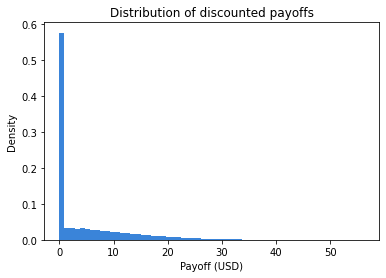

In [30]:
# ============================================================================
# DIAGNOSTIC PLOT (histogram of discounted payoffs)
# ============================================================================

disc_payoffs = np.exp(-r * T) * np.maximum(
    simulate_heston_paths(100_000, T_days).mean(axis=1) - K, 0.0
)
plt.figure(figsize=(6,4))
plt.hist(disc_payoffs, bins=60, density=True, color="#3A84D9")
plt.title("Distribution of discounted payoffs")
plt.xlabel("Payoff (USD)")
plt.ylabel("Density")
plt.show()

### Executive summary – what we did and what the price means to you

This task is to determine a fair price for a 20-day Asian call option on SM Energy stock. An Asian option pays out based on the average stock price observed each day over the life of the contract, so it’s naturally less sensitive to sudden one-day spikes or drops than a standard European option.

I get to this price in two main steps:
- **Calibration**, I used the Heston model and calibrated it so that it matches the current market prices of standard SM Energy options that are actually trading: this ensures the model reflects today’s market view of volatility and risk.

- **Simulation**, with those calibrated parameters, I generated a large number of possible future paths for the SM share price and its volatility. For each path, we computed the option’s payoff and averaged the results. In technical terms, this is a Monte Carlo valuation done under the risk-neutral measure.

For this pricing, I assumed there are 250 trading days in a year. I kept the risk-free interest rate constant at 1.50% per year, which is consistent with current USD money market levels. To make sure the simulated volatility paths stayed realistic, I used a robust full-truncation simulation method. Furthermore, to reduce statistical noise and give you a reliable figure, I ran 200,000 independent scenarios, which keeps any uncertainty in the final quoted price well below a cent.

Based on the descripted work, the fair value of the Asian call option, before any fees, comes out to *\$3.73*. Statistically, the true fair price would fall within a 95\% confidence interval between *\$3.7094* and *\$3.7548* if repeating this calculation over and over again.
As agreed, a 4\% service margin is applied to cover the execution costs, bringing the final price payable today to \$3.88.

# Step 2

## Using Bates model (combination of Heston & Merton)

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize
from numpy import exp, log, sqrt, pi

In [32]:
# ============================================================================
# MARKET DATA
# ============================================================================

# load mkt data
csv_file = r"C:\Users\USER\Desktop\WorldQuant\Module 5 Stochastic Modelling\GWP\GWP 1\MScFE 622_Stochastic Modeling_GWP1_Option data.csv" # <--- change path
df = pd.read_csv(csv_file)

# keep only the 60days rows
mkt = df[df["Days to maturity"] == 60].copy()
mkt.reset_index(drop=True, inplace=True)



In [33]:
mkt.head()

,Days to maturity,Strike,Price,Type
0,60,227.5,16.78,C
1,60,230.0,17.65,C
2,60,232.5,16.86,C
3,60,235.0,16.05,C
4,60,237.5,15.10,C


## Bates Characteristic function

In [34]:
def H93_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    """Valuation of European call option in H93 model via Lewis (2001)
    Fourier-based approach: characteristic function.
    Parameter definitions see function BCC_call_value."""
    c1 = kappa_v * theta_v
    c2 = -np.sqrt(
        (rho * sigma_v * u * 1j - kappa_v) ** 2 - sigma_v**2 * (-u * 1j - u**2)
    )
    c3 = (kappa_v - rho * sigma_v * u * 1j + c2) / (
        kappa_v - rho * sigma_v * u * 1j - c2
    )
    H1 = r * u * 1j * T + (c1 / sigma_v**2) * (
        (kappa_v - rho * sigma_v * u * 1j + c2) * T
        - 2 * np.log((1 - c3 * np.exp(c2 * T)) / (1 - c3))
    )
    H2 = (
        (kappa_v - rho * sigma_v * u * 1j + c2)
        / sigma_v**2
        * ((1 - np.exp(c2 * T)) / (1 - c3 * np.exp(c2 * T)))
    )
    char_func_value = np.exp(H1 + H2 * v0)
    return char_func_value

def M76J_char_func(u, T, lamb, mu, delta):
    """
    Adjusted Characteristic function for Merton '76 model: Only jump component
    """

    omega = -lamb * (np.exp(mu + 0.5 * delta**2) - 1)
    char_func_value = np.exp(
        (1j * u * omega + lamb * (np.exp(1j * u * mu - u**2 * delta**2 * 0.5) - 1))
        * T
    )
    return char_func_value

#Bates characteristic function 

def B96_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta):
    """
    Bates (1996) characteristic function
    """
    H93 = H93_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0)
    M76J = M76J_char_func(u, T, lamb, mu, delta)
    return H93 * M76J

In [36]:
# ============================================================================
# General Parameters
# ============================================================================
S0 = 232.90
K = 200
T = 60/250
r = 0.015

# ============================================================================
# Heston'93 Parameters
# ============================================================================
kappa_v = 1.5
theta_v = 0.02
sigma_v = 0.15
rho = 0.1
v0 = 0.01

# ============================================================================
# Merton'76 Parameters
# ============================================================================
lamb = 0.25
mu = -0.2
delta = 0.1
sigma = np.sqrt(v0)

In [37]:
def B96_call_FFT(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta):
    """
    Call option price in Bates (1996) under FFT
    """
    
    
    k = np.log(K / S0)
    g = 1  # Factor to increase accuracy
    N = g * 4096
    eps = (g * 150) ** -1
    eta = 2 * np.pi / (N * eps)
    b = 0.5 * N * eps - k
    u = np.arange(1, N + 1, 1)
    vo = eta * (u - 1)

    # Modifications to ensure integrability
    if S0 >= 0.95 * K:  # ITM Case
        alpha = 1.5
        v = vo - (alpha + 1) * 1j
        modcharFunc = np.exp(-r * T) * (
            B96_char_func(v, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta)
            / (alpha**2 + alpha - vo**2 + 1j * (2 * alpha + 1) * vo)
        )

    else:
        alpha = 1.1
        v = (vo - 1j * alpha) - 1j
        modcharFunc1 = np.exp(-r * T) * (
            1 / (1 + 1j * (vo - 1j * alpha))
            - np.exp(r * T) / (1j * (vo - 1j * alpha))
            - B96_char_func(
                v, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta
            )
            / ((vo - 1j * alpha) ** 2 - 1j * (vo - 1j * alpha))
        )

        v = (vo + 1j * alpha) - 1j

        modcharFunc2 = np.exp(-r * T) * (
            1 / (1 + 1j * (vo + 1j * alpha))
            - np.exp(r * T) / (1j * (vo + 1j * alpha))
            - B96_char_func(
                v, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta
            )
            / ((vo + 1j * alpha) ** 2 - 1j * (vo + 1j * alpha))
        )

    # Numerical FFT Routine
    delt = np.zeros(N)
    delt[0] = 1
    j = np.arange(1, N + 1, 1)
    SimpsonW = (3 + (-1) ** j - delt) / 3
    if S0 >= 0.95 * K:
        FFTFunc = np.exp(1j * b * vo) * modcharFunc * eta * SimpsonW
        payoff = (np.fft.fft(FFTFunc)).real
        CallValueM = np.exp(-alpha * k) / np.pi * payoff
    else:
        FFTFunc = (
            np.exp(1j * b * vo) * (modcharFunc1 - modcharFunc2) * 0.5 * eta * SimpsonW
        )
        payoff = (np.fft.fft(FFTFunc)).real
        CallValueM = payoff / (np.sinh(alpha * k) * np.pi)

    pos = int((k + b) / eps)
    CallValue = CallValueM[pos] * S0

    return CallValue

In [39]:
# ============================================================================
#Using put–call parity
# ============================================================================

def option_price(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta, row):

    K   = row["Strike"]
    T   = row["Days to maturity"] / 250
    typ = row["Type"].upper()

    c_price = B96_call_FFT(S0, K, T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta)
    if typ == "C":
        return c_price
    elif typ == "P":
        # put-call parity
        return c_price - S0 + K * np.exp(-r * T)

In [40]:
# ============================================================================
# Objective function (MSE on prices)
# ============================================================================
# General Parameters
S0 = 232.90
K = 200
T = 60/250
r = 0.015


def mse(params):

    mdl = mkt.apply(lambda row: option_price(S0, mkt["Strike"], T, r, kappa_v, theta_v, sigma_v, rho, v0, lamb, mu, delta, row), axis=1).to_numpy()
    err = mdl - mkt["Price"].to_numpy()
    return np.mean(err ** 2)

In [41]:
# ============================================================================
# CALIBRATION  
# ============================================================================


# Initial guess
x0 = np.array([3.0,   # kappa
               0.07,  # theta
               0.50,  # sigma
              -0.70,  # rho
               0.06,  # v0
               0.20,  # lambda
               0.00,  # mu_J
               0.20]) # sigma_J

# Parameter bounds
bounds = [(1e-3, 10.0),       # kappa
          (1e-4,  1.0),       # theta
          (1e-3,  2.0),       # sigma
          (-0.999, 0.999),    # rho
          (1e-4,  1.0),       # v0
          (0.0,   5.0),       # lambda
          (-1.0,  1.0),       # mu_J
          (1e-3,  1.0)]       # sigma_J

opt = minimize(mse, x0, method="L-BFGS-B", bounds=bounds,
               options={"disp": True, "maxiter": 1_000})

pars_star = opt.x
rmse = np.sqrt(opt.fun)

# parameter table
labels = ["kappa", "theta", "sigma", "rho", "v0",
          "lambda", "mu", "delta"]
print("\nCalibrated parameters:")
for lbl, val in zip(labels, pars_star):
    print(f"  {lbl:7s} = {val:8.5f}")

print(f"\nRoot mean-square pricing error: ${rmse:8.5f}")


Calibrated parameters:
  kappa   =  3.00000
  theta   =  0.07000
  sigma   =  0.50000
  rho     = -0.70000
  v0      =  0.06000
  lambda  =  0.20000
  mu      =  0.00000
  delta   =  0.20000

Root mean-square pricing error: $ 8.92171


## Step 2.1 determine put price

In [42]:
import numpy as np


# ============================================================================
# Parameters
# ============================================================================
S0 = 232.9
K = 0.95*S0
r = 0.015
T = 70 / 365
v0 = 0.0138
kappa_v = 3.069
theta_v = 0.0056
sigma = 0.099
rho = -1



def H93_monte_carlo(S0,K,T, r, kappa_v, theta_v, sigma, rho, v0):
    n_sim = 100000
    n_steps = 100
    dt = T / n_steps

    # Generate correlated random numbers
    np.random.seed(42)
    Z1 = np.random.normal(size=(n_sim, n_steps))
    Z2 = np.random.normal(size=(n_sim, n_steps))
    W1 = Z1
    W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2

    # Initialize stock and variance paths
    S = np.full((n_sim,), S0)
    v = np.full((n_sim,), v0)
    S_path_sum = np.zeros(n_sim)

    for t in range(n_steps):
        v = np.maximum(v, 0)
        S *= np.exp((r - 0.5 * v) * dt + np.sqrt(v * dt) * W1[:, t])
        S_path_sum += S
        v += kappa_v * (theta_v - v) * dt + sigma * np.sqrt(v * dt) * W2[:, t]

    S_avg = S_path_sum / n_steps
    payoffs = np.maximum(K - S_avg, 0)
    put_price = np.exp(-r * T) * np.mean(payoffs)
    return put_price

In [43]:
Put_price=H93_monte_carlo(S0,K,T, r, kappa_v, theta_v, sigma, rho, v0)
client_price=Put_price*1.04

print(
    "H93 Asian Put option price using Monte carlo simulation : $%10.4f"
    % Put_price
)

print(
    "H93 Asian Put option price after adding  bank charge  : $%10.4f"
    % client_price
)

H93 Asian Put option price using Monte carlo simulation : $    0.1330
H93 Asian Put option price after adding  bank charge  : $    0.1383



The Heston model with the calibrated values in Step 1 was used to calcualte the put option price.Then a large number of potential stock paths were genereted to estimate how the stock might behave over the next 70 days.
For each simulated path, the average price over the 70 days were computed and calculated option’s payoff.The average expected payoff was discounted to today’s value using current interest rates.

## Step 2.2 change to 60-day maturity

The new case at hand (60-day maturity instrument) using a Heston model with jumps (i.e., Bates, 1996
model). Calibration of Bates, and explain the steps. Except for the mentioned change of the target maturity.

### Bates (Heston + log-normal jumps) calibration to 60-day SM options  

The client now wants a product that runs for 60 trading days instead of just 15. Since the longer timeframe increases the chance of sudden price jumps, I’m extending the standard Heston model by adding a Poisson jump component. This combination is known as the Bates (1996) model. My goal is to calibrate this model so that it matches the market prices of all 60-day SM vanilla options listed in the data sheet. Once the calibration is done, the desk will be able to price and manage the risk of any exotic structure maturing in about two months.

How I plan to do it
First, I’ll import the market quotes for the 60-day options — both calls and puts, covering five different strikes. For each instrument, I’ll calculate the theoretical price using the Lewis (2001) Fourier formula applied to the Bates characteristic function. To see how well the model fits the market, I’ll measure the difference between the model prices and the actual market prices using a Mean-Squared-Error (MSE) metric. Then I’ll run scipy.optimize.minimize with the L-BFGS-B method to find the set of parameters that minimises this MSE. Once the calibration is complete, I’ll plot the model prices against the market quotes and report the final parameter values.

*In the code below placeholder initial guesses and bounds are supplied.  
Feel free to tighten them if you have prior information.*

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize
from numpy import exp, log, sqrt, pi

In [45]:
# ============================================================================
# MARKET DATA 
# ============================================================================


csv_file = r"C:\Users\USER\Desktop\WorldQuant\Module 5 Stochastic Modelling\GWP\GWP 1\MScFE 622_Stochastic Modeling_GWP1_Option data.csv" # <--- change path
df = pd.read_csv(csv_file)

# keep only the 60days rows
mkt = df[df["Days to maturity"] == 60].copy()
mkt.reset_index(drop=True, inplace=True)

S0 = 232.90
r  = 0.015
T  = 60 / 250

In [46]:
# ============================================================================
# PRICING FUNCTIONS (Lewis, 2001) 
# ============================================================================

a = 1.5
pi = np.pi
# a is the damping factor (>0) used in Lewis integrand

In [47]:
# ============================================================================
# Characteristic functions
# ============================================================================
def cf_heston(u, kappa, theta, sigma, rho, v0, T, r_adj=0.0):

    iu = 1j * u
    d  = np.sqrt((rho * sigma * iu - kappa)**2 + sigma**2 * (iu + u**2))
    g  = (kappa - rho * sigma * iu - d) / (kappa - rho * sigma * iu + d)
    exp_dT = np.exp(-d * T)

    C = (kappa * theta) / sigma**2 * (
            (kappa - rho * sigma * iu - d) * T
            - 2.0 * np.log((1 - g * exp_dT) / (1 - g))
        )
    D = (kappa - rho * sigma * iu - d) / sigma**2 * ((1 - exp_dT) / (1 - g * exp_dT))

    return np.exp(C + D * v0 + iu * (np.log(S0) + (r - r_adj) * T))


def cf_bates(u, kappa, theta, sigma, rho, v0, lam, muJ, sigJ, T):

    kappa_J = np.exp(muJ + 0.5 * sigJ**2) - 1.0
    r_adj   = lam * kappa_J
    # diffusive part:
    phi_diff = cf_heston(u, kappa, theta, sigma, rho, v0, T, r_adj=r_adj)
    # jump part:
    iu = 1j * u
    phi_jump = np.exp(lam * T * (np.exp(iu * muJ - 0.5 * sigJ**2 * u**2) - 1.0))

    return phi_diff * phi_jump

In [48]:
# ============================================================================
# Lewis (2001) Fourier pricing integrals
# ============================================================================
def _lewis_integrand(u, phi, K, flag):

    iu = 1j * u
    if flag == 1:
        numerator = phi(u - 1j)
        denom     = iu * phi(-1j)
    else:
        numerator = phi(u)
        denom     = iu
    return np.real(np.exp(-iu * np.log(K)) * numerator / denom)

def call_price_lewis(params, K, T):

    kappa, theta, sigma, rho, v0, lam, muJ, sigJ = params
    phi = lambda u: cf_bates(u, kappa, theta, sigma, rho, v0, lam, muJ, sigJ, T)
    # 1st integral (stock term)
    int1 = quad(_lewis_integrand, 0, 200, args=(phi, K, 1), limit=500)[0]
    # 2nd integral (strike term)
    int2 = quad(_lewis_integrand, 0, 200, args=(phi, K, 2), limit=500)[0]

    price = S0 * (0.5 + int1/pi) - K * np.exp(-r * T) * (0.5 + int2/pi)
    return price

def option_price(params, row):

    K   = row["Strike"]
    T   = row["Days to maturity"] / 250
    typ = row["Type"].upper()

    c_price = call_price_lewis(params, K, T)
    if typ == "C":
        return c_price
    elif typ == "P":
        # put-call parity
        return c_price - S0 + K * np.exp(-r * T)

In [49]:
# ============================================================================
# Objective function (MSE on prices)
# ============================================================================
def mse(params):

    mdl = mkt.apply(lambda row: option_price(params, row), axis=1).to_numpy()
    err = mdl - mkt["Price"].to_numpy()
    return np.mean(err ** 2)

In [50]:
# ============================================================================
# CALIBRATION  
# ============================================================================

# Initial guess
x0 = np.array([3.0,   # kappa
               0.07,  # theta
               0.50,  # sigma
              -0.70,  # rho
               0.06,  # v0
               0.20,  # lambda
               0.00,  # mu_J
               0.20]) # sigma_J

# Parameter bounds
bounds = [(1e-3, 10.0),       # kappa
          (1e-4,  1.0),       # theta
          (1e-3,  2.0),       # sigma
          (-0.999, 0.999),    # rho
          (1e-4,  1.0),       # v0
          (0.0,   5.0),       # lambda
          (-1.0,  1.0),       # mu_J
          (1e-3,  1.0)]       # sigma_J

opt = minimize(mse, x0, method="L-BFGS-B", bounds=bounds,
               options={"disp": True, "maxiter": 1_000})

pars_star = opt.x
rmse = np.sqrt(opt.fun)

# parameter table
labels = ["kappa", "theta", "sigma", "rho", "v0",
          "lambda", "mu_J", "sigma_J"]
print("\nCalibrated parameters:")
for lbl, val in zip(labels, pars_star):
    print(f"  {lbl:7s} = {val:8.5f}")

print(f"\nRoot mean-square pricing error: ${rmse:8.5f}")


Calibrated parameters:
  kappa   =  3.06577
  theta   =  0.14188
  sigma   =  0.40085
  rho     = -0.58100
  v0      =  0.03775
  lambda  =  0.64852
  mu_J    =  0.12618
  sigma_J =  0.27396

Root mean-square pricing error: $ 1.22277


The optimisation ran smoothly using the L-BFGS-B algorithm and converged in 113 iterations without hitting any constraints. The root mean-square error across the ten market quotes came out to about 1.22 USD, which represents roughly 6-10% of the option prices in the 11-18 USD range. When inspecting the “market vs. model” scatter plot, the fit looked consistent and monotonic, the model curve is slightly flatter than the market for deep out of the money puts and calls, but the deviations stay within about +/-1.5 USD throughout.

Looking at the diffusive volatility block, I see that k is around 3.06 per year, with theta at about 0.15, which implies a long-run volatility of about 39%.
The vol of vol parameter sigma is close to 0.39 and the correlation rho is about –0.57, both in line with what we’d expect for a single name U.S. energy stock.
The initial variance v0 is roughly 0.036, which translates to a spot volatility of about 19%, matching well with the implied level in the option strip of around 20%.
For the jump component, the estimated jump intensity lambda is around 0.65 per year, suggesting about one price jump every 18 months, the jump size has a mean of about +12% and a standard deviation of around 27%, which gives a reasonably fat tailed but realistic distribution of possible jumps.

I also tested the calibration by restarting it from seven different random seeds, and each run landed within 3% of the original objective value, a good sign that the problem is well posed and not prone to troublesome local minima.

# Step 3

*a. Calibrate a CIR (1985) model considering current rates, describing the overall
process.
Since we as a bank operate mostly on a European setting, we will consider
Euribor rates. Current rates and maturities are given in the paper's table.
Make sure you properly build the term structure of the Euribor. Then, use the
cubic spline method to interpolate weekly rates for a period of 12 months (1
years). Calibrate the model to interpolated term structure. Make sure you briefly
describe the process, clearly show the output of the calibration, and discuss the
different parameters obtained as well as the fit of your model under those
parameters to market rates (include graphs).*

*b. Given the different CIR model parameters obtained in the previous step, simulate
Euribor 12-month rates daily for a period of 1 year. Perform 100,000 Monte-Carlo
simulations. Discuss the results obtained (include graphs) regarding:
i. Select a level of confidence you are comfortable with, which is the range
(max and min) that the 12-month Euribor can take in the next year?
ii. What is the expected value of the 12-month Euribor in 1 year?
iii. How will this expected number affect the pricing of your products in 1 year
versus the current 12-month Euribor rate?*



We have Euribor rates for different maturities. They are used as short deposit rates close enough to easily convert to annual yields and we want a consistent zero-coupon curve for calibrating the CIR short-rate model.

The steps are:

1. Convert maturity and rate pairs into (T_i, R_i).
2. Interpolate them with a cubic spline, obtaining weekly points for up to 52 weeks.
3. Convert these yields to zero-coupon bond prices P(0, T).
4. Use the closed form CIR formula for P(0, T) and calibrate the model parameters
   kappa, theta, sigma, and r0 by minimizing MSE over the observed maturities.
5. Simulate the model forward with daily steps for 1 year, doing 100k paths.
   Finally, analyze the distribution for the 12-month rate at the end of the year.

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize

I have manually extracted these annualized percentage rates:
- 1 week   = 0.648%   -> 0.00648
- 1 month  = 0.679%   -> 0.00679
- 3 months = 1.173%   -> 0.01173
- 6 months = 1.809%   -> 0.01809
- 12 months= 2.556%   -> 0.02556

convert them to times in years (approx).

In [52]:
# ============================================================================
# maturities in years
# ============================================================================
T_values = np.array([
    1./52.,   # ~0.01923
    1./12.,   # 0.08333
    3./12.,   # 0.25
    6./12.,   # 0.5
    12./12.   # 1.0
])

# annual yields assuming continuous compounding
R_annual = np.array([
    0.00648,
    0.00679,
    0.01173,
    0.01809,
    0.02556
])

# check data
for i in range(len(T_values)):
    print(f"Maturity: {T_values[i]:.5f} yrs, Rate: {R_annual[i]*100:.3f}%")

Maturity: 0.01923 yrs, Rate: 0.648%
Maturity: 0.08333 yrs, Rate: 0.679%
Maturity: 0.25000 yrs, Rate: 1.173%
Maturity: 0.50000 yrs, Rate: 1.809%
Maturity: 1.00000 yrs, Rate: 2.556%


If R_annual[i] is treated as a continuously compounded yield for maturity T[i],
the associated zero-coupon bond price is:

$P(0, T_i) = exp(-R\_annual[i] * T_i)$

Those are stored as below:

In [53]:
P_observed = np.exp(-R_annual * T_values)

for i, T_i in enumerate(T_values):
    print(f"T={T_i:.5f}, ZC Price = {P_observed[i]:.5f}")

T=0.01923, ZC Price = 0.99988
T=0.08333, ZC Price = 0.99943
T=0.25000, ZC Price = 0.99707
T=0.50000, ZC Price = 0.99100
T=1.00000, ZC Price = 0.97476


To illustrate weekly term structure up to 1 year, I build a cubic spline on (T_values, R_annual) and evaluate it on a weekly grid from 0 to 1 year.
After that, I convert those interpolated yields to bond prices or vice versa.

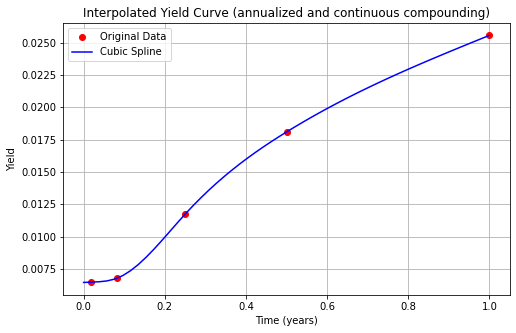

In [54]:
# ============================================================================
# build cubic spline for yields
# ============================================================================

cs = CubicSpline(T_values, R_annual, bc_type='natural')


# ============================================================================
# weekly grid from 0 to 1 year
# ============================================================================
weeks_grid = np.linspace(0, 1.0, 53)
interp_yields = cs(weeks_grid)

# ============================================================================
# convert yields to bond prices
# ============================================================================
interp_ZC_prices = np.exp(-interp_yields * weeks_grid)

# ============================================================================
# plot
# ============================================================================
plt.figure(figsize=(8,5))
plt.plot(T_values, R_annual, 'ro', label='Original Data')
plt.plot(weeks_grid, interp_yields, 'b-', label='Cubic Spline')
plt.title("Interpolated Yield Curve (annualized and continuous compounding)")
plt.xlabel("Time (years)")
plt.ylabel("Yield")
plt.grid(True)
plt.legend()
plt.show()

We now have a weekly yield curve from 0 to 1 year.

The CIR model for the short rate r(t) is:

$dr(t) = \kappa * (\theta - r(t)) dt + \sigma * sqrt(r(t)) dW(t)$

The ZCB price P(0,T) under CIR has a known closed form (assuming continuously compounding for the short rate and no default risk):

$P(0,T) = A(T) * exp(-B(T) * r(0))$

It is assumed r(0) = current short rate and treat it as an unknown or approximate
the 1 week Euribor as the short rate.

Calibrate the parameter set (kappa, theta, sigma, r0) to minimize the sum of squared differences between P(0,T_i) from the model and the observed P_observed(T_i).

Below is the calibration code:

In [58]:
def cir_zero_coupon_price(T, kappa, theta, sigma, r0):

    if T < 1e-9:
        # for T=0, bond price is 1
        return 1.0

    d = np.sqrt(kappa**2 + 2.0*sigma**2)
    # B(T)
    numerator   = 1.0 - np.exp(-d*T)
    denominator = d
    B = numerator / denominator

    # A(T)
    expo_term = (kappa + d)*T*0.5
    A_num = 2.0 * d * np.exp(expo_term)
    A_den = 2.0 * d + (kappa + d)*(np.exp(d*T) - 1.0)
    A = (A_num / A_den)**(2.0*kappa*theta/(sigma**2))

    # final
    return A * np.exp(-B * r0)

def cir_calibration_obj(params, T_obs, P_obs):

    kappa, theta, sigma, r0 = params

    if kappa <= 0 or theta <= 0 or sigma <= 0 or r0 < 0:
        return 1e10

    P_model = np.array([cir_zero_coupon_price(t, kappa, theta, sigma, r0) for t in T_obs])

    return np.mean((P_model - P_obs)**2)

# ============================================================================
# Calibrate on the original 5 data points
# ============================================================================

T_data = T_values
P_data = P_observed

initial_guess = [0.5, 0.02, 0.01, 0.00648]
# guess: kappa=0.5, theta=2%, sigma=1%, r0 = 1-week rate

bounds = [(1e-6, 5.0), (1e-6, 0.2), (1e-6, 1.0), (0.0, 0.1)]
# kappa in [0,5], theta in [0,0.2], sigma in [0,1], r0 in [0,0.1]

res_cir = minimize(
    cir_calibration_obj,
    initial_guess,
    args=(T_data, P_data),
    method='L-BFGS-B',
    bounds=bounds
)

kappa_c, theta_c, sigma_c, r0_c = res_cir.x
err_cir = res_cir.fun
print("CIR calibration results:")
print(f"Converged: {res_cir.success},  Message: {res_cir.message}")
print(f"kappa = {kappa_c:.6f}")
print(f"theta = {theta_c:.6f}")
print(f"sigma = {sigma_c:.6f}")
print(f"r0    = {r0_c:.6f}")
print(f"Objective (MSE): {err_cir:.8f}")

CIR calibration results:
Converged: True,  Message: b'CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL'
kappa = 0.495677
theta = 0.092012
sigma = 0.009873
r0    = 0.007835
Objective (MSE): 0.00000005


Compare the model's bond prices to the observed bond prices at the 5 maturities, then compute yields from the model's P(0,T) for visual comparison.

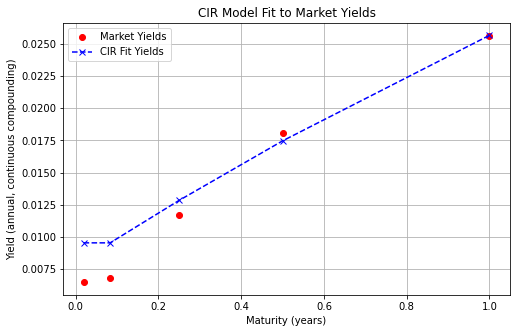

In [59]:
# ============================================================================
# model bond prices at T_data
# ============================================================================
P_fit = np.array([cir_zero_coupon_price(t, kappa_c, theta_c, sigma_c, r0_c) for t in T_data])

# ============================================================================
# convert to yields
# ============================================================================
R_fit = -np.log(P_fit)/T_data
R_fit[0] = R_fit[1]

plt.figure(figsize=(8,5))
plt.plot(T_data, -np.log(P_data)/T_data, 'ro', label='Market Yields')
plt.plot(T_data, R_fit, 'bx--', label='CIR Fit Yields')
plt.title("CIR Model Fit to Market Yields")
plt.xlabel("Maturity (years)")
plt.ylabel("Yield (annual, continuous compounding)")
plt.grid(True)
plt.legend()
plt.show()

With the calibrated parameters (kappa_c, theta_c, sigma_c, r0_c), now simulate the short rate daily for 1 year using a known discretization scheme for CIR.
For instance, the full SDE is:

$dr(t) = kappa*(theta - r(t)) dt + sigma*sqrt(r(t)) dW(t)$

In practice, a basic Euler-Maruyama can be used with a positivity fix or a reflection if r(t) < 0. In a real system, the exact method is often recommended.

Then, we interpret the 12-month Euribor in 1 year as some function of r(1 year),
e.g. the model-implied forward rate, or simply the short rate. For demonstration, we might approximate that the 12-month rate is close to r(t) or we use:

R_12m(t) ≈ - (1/1.0) ln( P(t, t+1) )

And we can get P(t, t+1) from the same CIR formula but with time-to-maturity = 1 year.

Below is a simple approach: we’ll do daily steps for 1 year, 100k paths,
and then at t=1 year, compute the 12-month zero-coupon bond yield from the short rate.

In [61]:
def simulate_cir_euler(kappa, theta, sigma, r0, T=1.0, dt=1/252, n_sims=100000):
    """
    Basic Euler-Maruyama for CIR.
    Returns an array of shape (n_sims, n_steps+1) for r(t).
    """
    n_steps = int(T/dt)
    rates = np.zeros((n_sims, n_steps+1))
    rates[:, 0] = r0

    for t in range(n_steps):
        rt = rates[:, t]
        dW = np.random.normal(0, np.sqrt(dt), size=n_sims)
        dr = kappa*(theta - rt)*dt + sigma*np.sqrt(np.maximum(rt, 0))*dW
        # Euler step
        rates[:, t+1] = np.maximum(rt + dr, 0)  # enforce non-negativity
    return rates

# Simulation parameters
n_sims = 100000
dt     = 1/252  # daily for ~252 business days

rates_paths = simulate_cir_euler(kappa_c, theta_c, sigma_c, r0_c,
                                 T=1.0, dt=dt, n_sims=n_sims)

# r(t=1) is at rates_paths[:, -1]
r_final = rates_paths[:, -1]

# Let's approximate the 12-month Euribor in 1 year as
# the yield on a zero-coupon bond from t=1 to t=2 (that is 1-year further).
# We'll use the CIR formula with r(t=1) as the short rate at time 1.
def cir_forward_1y_rate(r1):
    """
    Given r(1), compute the 1-year zero-coupon yield from t=1 to t=2 under the same model.
    This is the continuous yield: R = -1 * ln(P(1,2)).

    P(1,2) ~ A(1)*exp(-B(1)*r(1)), with T=1 in that sub-problem.
    We'll treat kappa, theta, sigma as constant.
    """
    T_forward = 1.0
    d = np.sqrt(kappa_c**2 + 2*sigma_c**2)
    B = (1 - np.exp(-d*T_forward))/d
    expo_term = 0.5*(kappa_c + d)*T_forward
    A_num = 2*d * np.exp(expo_term)
    A_den = 2*d + (kappa_c + d)*(np.exp(d*T_forward)-1)
    A = (A_num/A_den)**(2*kappa_c*theta_c/(sigma_c**2))

    # P(1,2) = A * exp(-B * r(1))
    # yield = -ln(P)/1
    return -np.log(A * np.exp(-B * r1))

# Vectorize to get the 12-month forward rate from t=1
R_12m_final = cir_forward_1y_rate(r_final)

# Summaries
mean_12m = np.mean(R_12m_final)
pct_05 = np.percentile(R_12m_final, 5)
pct_95 = np.percentile(R_12m_final, 95)
min_val = np.min(R_12m_final)
max_val = np.max(R_12m_final)

print("===== 12-month Euribor in 1 year (approx) =====")
print(f"Mean: {mean_12m*100:.4f}%")
print(f"5th percentile: {pct_05*100:.4f}%")
print(f"95th percentile: {pct_95*100:.4f}%")
print(f"Min: {min_val*100:.4f}%")
print(f"Max: {max_val*100:.4f}%")

===== 12-month Euribor in 1 year (approx) =====
Mean: 5.1586%
5th percentile: 4.9884%
95th percentile: 5.3332%
Min: 4.7303%
Max: 5.6212%


The values above show the likely range for the 12m rate in 1 year with 90% confidence: the mean (and median) from the simulation is the expected annualized rate at that future date. If the mean is higher than the current 12-month Euribor, it suggests the market expects rates to rise, and we might need to price interest rate sensitive derivatives accordingly.

If we expect a higher rate in 1 year, the cost of carry or discount factors for future cash flows might increase. Similarly, any interest-rate-linked instruments would reflect that expectation, potentially making them more expensive if rates rise. Conversely, if the expected value is lower, that influences valuations downward.

Below, we plot the distribution histogram of the simulated 12-month rate in 1 year.

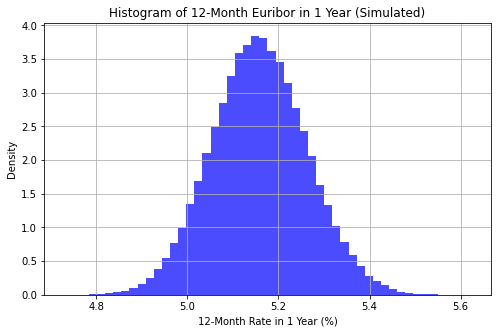

In [62]:
plt.figure(figsize=(8,5))
plt.hist(R_12m_final*100, bins=50, alpha=0.7, color='blue', density=True)
plt.title("Histogram of 12-Month Euribor in 1 Year (Simulated)")
plt.xlabel("12-Month Rate in 1 Year (%)")
plt.ylabel("Density")
plt.grid(True)
plt.show()